# Exam Score Predictor👩🏻‍🎓

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import gradio as gr

In [3]:
df=pd.read_csv('/content/student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
print('dataset information')
print(df.info())
print('no. of null values')
print(df.isnull().sum())

dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality             

# Cleaning the Dataset

In [5]:
# Filling Missing Values
df['parental_education_level']=df['parental_education_level'].fillna('Unknown')


In [6]:
# Checking no. of unique values in each column
df.nunique().sort_values(ascending=False)

,0
student_id,1000
exam_score,480
attendance_percentage,320
study_hours_per_day,78
sleep_hours,68
social_media_hours,60
netflix_hours,51
mental_health_rating,10
age,8
exercise_frequency,7


In [7]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [8]:
# Encoding Categorical columns
df=pd.get_dummies(df, columns=['parental_education_level',
        'gender',
        'internet_quality',
        'diet_quality'], drop_first=True)

le=LabelEncoder()
df['part_time_job']=le.fit_transform(df['part_time_job'])
df['extracurricular_participation']=le.fit_transform(df['extracurricular_participation'])

In [9]:
# dropping columns which are not needed
df.drop( columns='student_id', axis=1, inplace=True)


In [10]:
df.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,extracurricular_participation,exam_score,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,gender_Male,gender_Other,internet_quality_Good,internet_quality_Poor,diet_quality_Good,diet_quality_Poor
0,23,0.0,1.2,1.1,0,85.0,8.0,6,8,1,56.2,False,True,False,False,False,False,False,False,False
1,20,6.9,2.8,2.3,0,97.3,4.6,6,8,0,100.0,True,False,False,False,False,False,False,True,False
2,21,1.4,3.1,1.3,0,94.8,8.0,1,1,0,34.3,True,False,False,True,False,False,True,False,True
3,23,1.0,3.9,1.0,0,71.0,9.2,4,1,1,26.8,False,True,False,False,False,True,False,False,True
4,19,5.0,4.4,0.5,0,90.9,4.9,3,1,0,66.4,False,True,False,False,False,True,False,False,False


# Exploratory Data Analysis

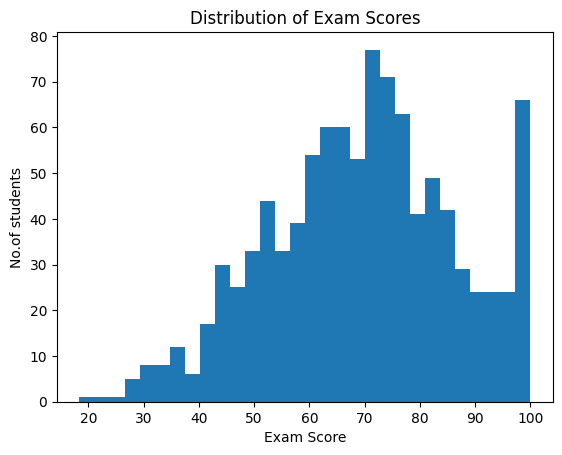

In [11]:
plt.hist(df['exam_score'], bins=30)
plt.xlabel('Exam Score')
plt.ylabel('No.of students')
plt.title('Distribution of Exam Scores')
plt.show()

The score distribution is positively skewed, with more than 50% students scoring above 60 and a small number of luxury vehicles appearing as high-value outliers.

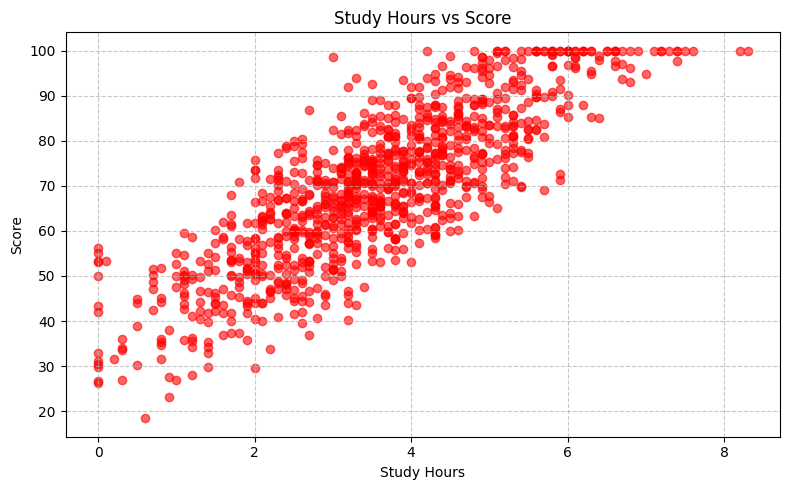

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(df["study_hours_per_day"], df["exam_score"], c='red',alpha=0.6)

plt.title("Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The scatter plot indicates a positive relationship between study hours per day and exam score. Students w high study hours tend to score more in the exam. A very few highly intelligent students appear as outliers.

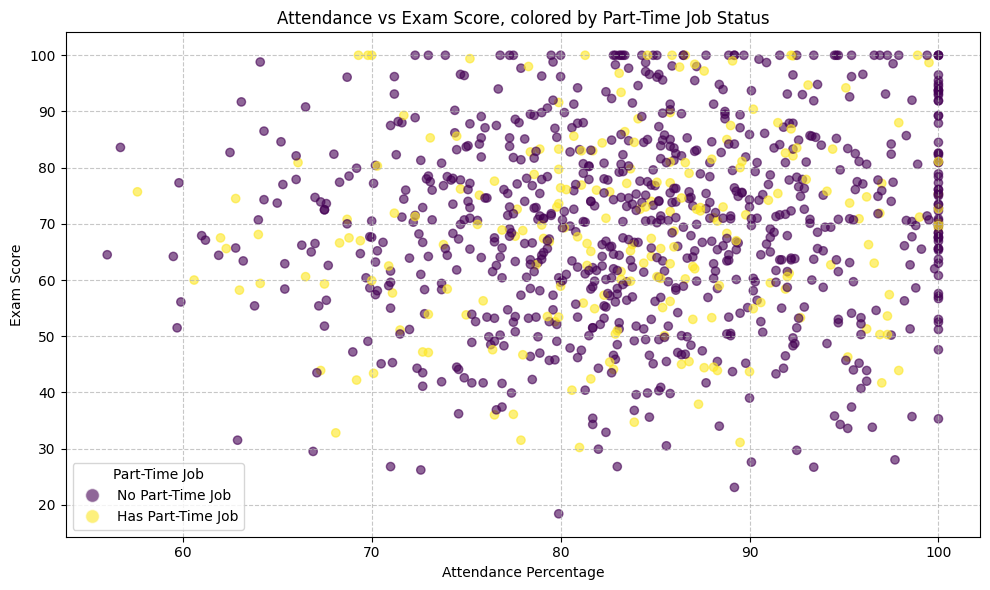

In [13]:
plt.figure(figsize=(10,6))

# Color points based on 'part_time_job' (0 or 1), add transparency
scatter = plt.scatter(df['attendance_percentage'], df['exam_score'],
                      c=df['part_time_job'], cmap='viridis', alpha=0.6)

plt.title("Attendance vs Exam Score, colored by Part-Time Job Status")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")

# Create a legend for 'part_time_job'
legend_labels = {0: 'No Part-Time Job', 1: 'Has Part-Time Job'}
handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[val],
                      markerfacecolor=scatter.cmap(scatter.norm(val)), markersize=10, alpha=0.6)
           for val in sorted(df['part_time_job'].unique())]
plt.legend(handles=handles, title="Part-Time Job")


plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Higher attendance is associated with slightly better exam performance, but the relationship is weak. Students with and without part-time jobs show similar score distributions, indicating that attendance alone does not fully explain exam outcomes.

The Bar graph shows the top 10 car brands. Ford being on the top with 86 count.

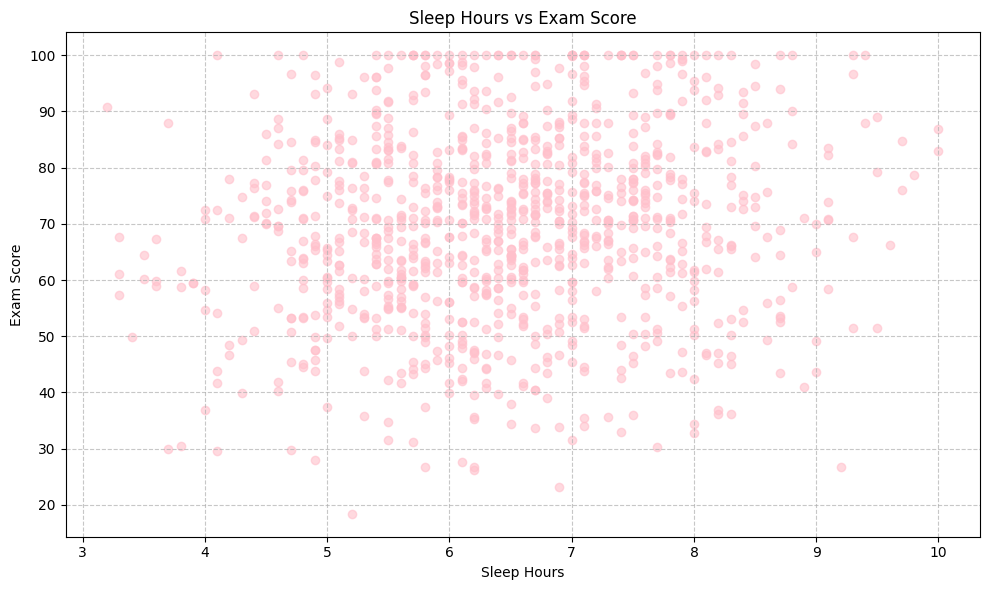

In [14]:
plt.figure(figsize=(10,6))

# Color points based on 'part_time_job' (0 or 1), add transparency
scatter = plt.scatter(df['sleep_hours'], df['exam_score'], c='pink', alpha=0.6)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")


plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The relationship between sleeping hours and Exam Score is not strong overall but students who sleep between 5 to 8 hours tend to perform better comparitively.

In [15]:
# Checking correlation between numerical columns
print(df.corr(numeric_only=True)['exam_score'].sort_values(ascending=False))

exam_score                              1.000000
study_hours_per_day                     0.825419
mental_health_rating                    0.321523
exercise_frequency                      0.160107
sleep_hours                             0.121683
attendance_percentage                   0.089836
gender_Other                            0.012976
parental_education_level_Unknown        0.008108
internet_quality_Poor                   0.003016
extracurricular_participation           0.000881
parental_education_level_High School   -0.002583
age                                    -0.008907
diet_quality_Good                      -0.010857
gender_Male                            -0.013191
part_time_job                          -0.026608
parental_education_level_Master        -0.040177
diet_quality_Poor                      -0.041602
internet_quality_Good                  -0.050804
social_media_hours                     -0.166733
netflix_hours                          -0.171779
Name: exam_score, dt

# Training the model


1. Linear Regression model

MAE: 4.189311054627602
R2: 0.8967502640380203
RMSE: 5.145506433284207


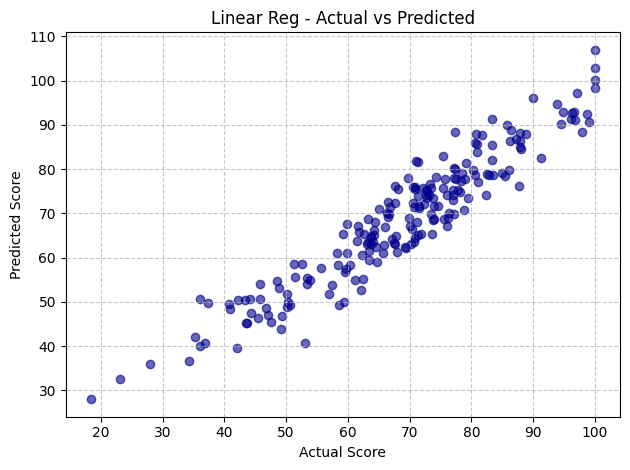

In [16]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

plt.scatter(y_test, y_pred, c='darkblue', alpha=0.6)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Linear Reg - Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

2. Random Forest Regressor model

MAE: 4.9397350000000015
R2: 0.8500569228501277
RMSE: 6.200787669723905


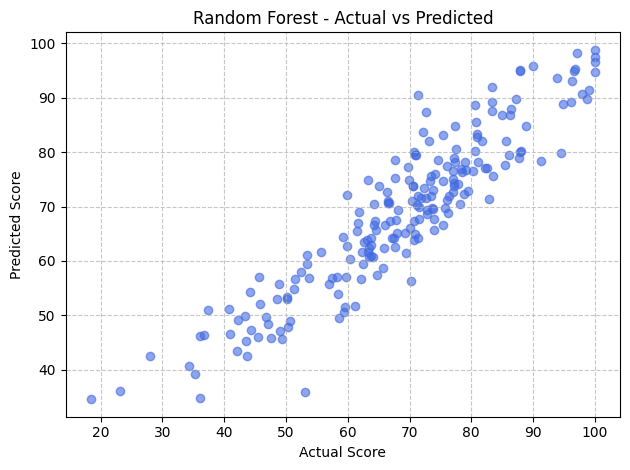

In [17]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf= RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_rf_pred=model_rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_rf_pred))
print("R2:", r2_score(y_test, y_rf_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_rf_pred))
print("RMSE:", rmse)

plt.scatter(y_test, y_rf_pred, c='royalblue', alpha=0.6)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Random Forest - Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

                  Feature  Importance
1     study_hours_per_day    0.707956
8    mental_health_rating    0.106118
2      social_media_hours    0.038515
6             sleep_hours    0.037580
3           netflix_hours    0.034906
7      exercise_frequency    0.025269
5   attendance_percentage    0.020547
0                     age    0.008981
17      diet_quality_Good    0.002600
13            gender_Male    0.002519


3. Decision Tree Regressor

MAE: 7.418000000000001
R2: 0.6508040569623972
RMSE: 9.46276915072961


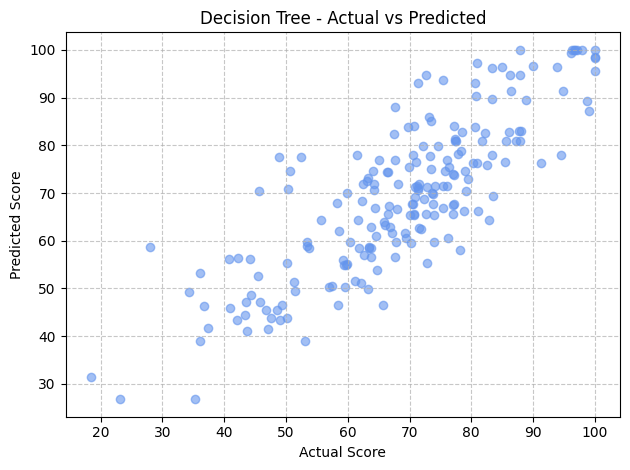

In [19]:

X = df.drop('exam_score', axis=1)
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_df= DecisionTreeRegressor()
model_df.fit(X_train, y_train)
y_df_pred=model_df.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_df_pred))
print("R2:", r2_score(y_test, y_df_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_df_pred))
print("RMSE:", rmse)

plt.scatter(y_test, y_df_pred, c='cornflowerblue', alpha=0.6)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Decision Tree - Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
    "R2": [0.89,0.85,0.64],
    "MAE": [4.18,4.93,7.56],
    "RMSE": [5.14,6.20,9.52]
})

print(results)

               Model    R2   MAE  RMSE
0  Linear Regression  0.89  4.18  5.14
1      Random Forest  0.85  4.93  6.20
2      Decision Tree  0.64  7.56  9.52


Three regression models were evaluated: Linear Regression, Random Forest Regressor, and Decision Tree Regressor. Linear Regression achieved the best performance with an R² score of approximately 0.90 and the lowest prediction error, indicating that study habits and lifestyle factors have a strong linear relationship with student exam performance.

Building Web app for Predicting Students Exam Score

In [25]:
X.columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'part_time_job', 'attendance_percentage', 'sleep_hours',
       'exercise_frequency', 'mental_health_rating',
       'extracurricular_participation', 'parental_education_level_High School',
       'parental_education_level_Master', 'parental_education_level_Unknown',
       'gender_Male', 'gender_Other', 'internet_quality_Good',
       'internet_quality_Poor', 'diet_quality_Good', 'diet_quality_Poor'],
      dtype='object')

In [26]:
import gradio as gr

def predict(age,
            study_hours_per_day,
            social_media_hours,
            netflix_hours,
            part_time_job,
            attendance_percentage,
            sleep_hours,
            exercise_frequency,
            mental_health_rating,
            extracurricular_participation,
            parental_education,
            gender,
            internet_quality,
            diet_quality):

    # Parent Education Encoding
    hs = 0
    master = 0
    unknown = 0

    if parental_education == "High School":
        hs = 1
    elif parental_education == "Master":
        master = 1
    else:
        unknown = 1

    # Gender Encoding
    gender_male = 0
    gender_other = 0

    if gender == "Male":
        gender_male = 1
    elif gender == "Other":
        gender_other = 1
    # Female = both 0

    # Internet Quality Encoding
    internet_good = 0
    internet_poor = 0

    if internet_quality == "Good":
        internet_good = 1
    else:
        internet_poor = 1

    # Diet Quality Encoding
    diet_good = 0
    diet_poor = 0

    if diet_quality == "Good":
        diet_good = 1
    else:
        diet_poor = 1

    prediction = model.predict([[
        age,
        study_hours_per_day,
        social_media_hours,
        netflix_hours,
        part_time_job,
        attendance_percentage,
        sleep_hours,
        exercise_frequency,
        mental_health_rating,
        extracurricular_participation,
        hs,
        master,
        unknown,
        gender_male,
        gender_other,
        internet_good,
        internet_poor,
        diet_good,
        diet_poor
    ]])

    return round(prediction[0], 2)


interface = gr.Interface(
    fn=predict,

    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Study Hours Per Day"),
        gr.Number(label="Social Media Hours"),
        gr.Number(label="Netflix Hours"),
        gr.Number(label="Part Time Job (0 = No, 1 = Yes)"),
        gr.Number(label="Attendance Percentage"),
        gr.Number(label="Sleep Hours"),
        gr.Number(label="Exercise Frequency"),
        gr.Number(label="Mental Health Rating"),
        gr.Number(label="Extracurricular Participation (0 = No, 1 = Yes)"),

        gr.Dropdown(
            ["High School", "Master", "Unknown"],
            label="Parent Education"
        ),

        gr.Dropdown(
            ["Female", "Male", "Other"],
            label="Gender"
        ),

        gr.Dropdown(
            ["Good", "Poor"],
            label="Internet Quality"
        ),

        gr.Dropdown(
            ["Good", "Poor"],
            label="Diet Quality"
        )
    ],

    outputs=gr.Number(label="Predicted Exam Score"),

    title="🎓 Student Exam Score Predictor",

    description="Enter student details to predict the exam score."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://964a283c1607a4f4c7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
